<h1><font color="#113D68" size=6>00_pipeline</font></h1>

<br><br>
<div style="text-align: right">
<font color="#113D68" size=3>Feng </font><br>

</div>

---

## Project Overview 
This pipeline implements a complete workflow for converting small tabular datasets into images and performing transfer learning with pretrained CNN models.
整体流程类似pytorch_custom_dataset这个文件（要改成使用5-Fold cross validation，使用stratifiedKFold），暂时先不go modular：想法是

1.使用dataset文件夹里的iris数据集，

2.tabular-to-image transformation method使用TINTOlib（等把TINTOlib example文件演示流程），

3.transfer learning model选择EfficientNet_V2_M_Weights.IMAGENET1K_V1，

4.metric: accuracy, loss curves

5.Statistic test: 使用 Friedman Test + Nemenyi Post-hoc Test 或 Wilcoxon Signed-Rank Test

### Project Structure
```
PyTorch_26project/
├── data/
│   └── 1.Numerical_iris/
│       └── iris.data          # UCI Iris 数据集 / UCI Iris dataset
├── notebook/
│   └── pipeline.ipynb         # 主 pipeline 文件 / Main pipeline file
└── output/
    ├── tinto_images/          # TINTO 生成的图像 / TINTO generated images
    └── results/               # 实验结果 / Experiment results
```
### Key Features
1. **Tabular-to-Image Transformation**: Uses TINTOlib methods (TINTO, IGTD, SuperTML, etc.) to convert structured data into synthetic images.
     **表格到图像的转换**: 使用TINTOlib方法（TINTO, IGTD, SuperTML等）将结构化数据转换为合成图像。

3. **5-Fold Stratified Cross-Validation** : Ensures robust evaluation by maintaining class distribution across folds.
   **5折分层交叉验证**：通过保持每折的类别分布，确保评估的稳健性。

5. **Transfer Learning with Pretrained Models**: Leverages state-of-the-art CNNs (EfficientNet, ResNet, etc.) pretrained on ImageNet.
   **预训练模型的迁移学习**：利用在ImageNet上预训练的最先进CNN模型（EfficientNet, ResNet等）。

7. **Comparative Study Framework**: Designed for systematic comparison of different transformation methods and model architectures on small-sample datasets.
   **对比研究框架**：专为在小样本数据集上系统比较不同转换方法和模型架构而设计。

### Pipeline Steps
1. 数据加载与探索 / Data loading and exploration
2. TINTOlib 图像转换 / TINTOlib image transformation
3. 自定义数据集类 / Custom dataset class
4. 模型定义 (EfficientNet_V2_M) / Model definition
5. 5-Fold Stratified Cross Validation / 5折分层交叉验证
6. 训练与评估 / Training and evaluation
7. 统计测试 (Friedman + Nemenyi / Wilcoxon) / Statistical tests
8. 结果保存 / Results saving


## 00. Import Libraries
This cell imports all necessary libraries for the pipeline, including:

- **Standard libraries**: os, pathlib, typing for file operations and type hints 用于文件操作和类型提示
- **Data processing**: numpy, pandas for data manipulation 用于数据操作
- **Visualization**: matplotlib, seaborn for plotting用于绘图
- **TINTOlib**: Custom library for tabular-to-image transformation 用于表格到图像转换的自定义库
- **PyTorch ecosystem**: torch, torchvision, torch.nn for deep learning 用于深度学习
- **Scikit-learn**: For cross-validation, preprocessing, and metrics 用于交叉验证、预处理和评估指标
- **Statistical tests**: scipy, scikit-posthocs for comparative analysis 用于对比分析
- **Progress bar**: tqdm for monitoring training progress 用于监控训练进度

In [90]:
# Standard library imports
import os
import math
import shutil
from typing import Tuple, List, Dict, Optional
import random
import matplotlib.pyplot as plt
import cv2

# Third-party library imports
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import requests
import zipfile 
import warnings
warnings.filterwarnings('ignore')

# Custom TINTO library imports
from TINTOlib.tinto import TINTO
from TINTOlib.supertml import SuperTML
from TINTOlib.igtd import IGTD
from TINTOlib.refined import REFINED
from TINTOlib.barGraph import BarGraph
from TINTOlib.distanceMatrix import DistanceMatrix
from TINTOlib.combination import Combination
from TINTOlib.featureWrap import FeatureWrap
from TINTOlib.bie import BIE

# PyTorch imports
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, models
from torchvision.models import EfficientNet_V2_M_Weights

# Scikit-learn imports
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

# Statistical Test
from scipy import stats
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# Progress bar
from tqdm import tqdm
#from tqdm.notebook import tqdm

# check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")
print("All libraries imported successfully!")

Using device: cuda
torch version: 2.2.2
torchvision version: 0.17.2
All libraries imported successfully!


## 01. Configuration and Path setup


This cell defines the `Config` class which centralizes all configuration parameters for the experiment.

### Key Configuration Parameters

| Parameter  | Description  | Value  |
|:---|:---|:---|
| `IMG_SIZE` | Size of TINTO-generated images  | 64 |
| `INPUT_SIZE` | Input size for pretrained models  | 224 |
| `NUM_CLASSES` | Number of target classes | 3 (Iris) |
| `EPOCHS` | Number of training epochs  | 15 |
| `BATCH_SIZE` | Mini-batch size | 16 |
| `LEARNING_RATE` | Learning rate for optimizer  | 1e-4 |
| `N_FOLDS` | Number of cross-validation folds | 5 |
| `SEED` | Random seed for reproducibility  | 42 |

### TINTO Methods Supported 
- `tinto`: TINTO (Tabular Image Transformation) / 表格图像转换
- `refined`: REFINED (Refined Feature Integration) / 精炼特征集成
- `igtd`: IGTD (Image Generation from Tabular Data) / 从表格数据生成图像
- `supertml`: SuperTML (Supervised Tabular-to-Image) / 监督表格到图像
- `bargraph`: BarGraph visualization / 条形图可视化
- `distancematrix`: Distance Matrix visualization / 距离矩阵可视化
- `combination`: Combination of methods / 方法组合

### Directory Structure Created / 创建的目录结构
```
output/
├── tinto_images/ # TINTO生成的图像 / TINTO generated images
│ ├── fold_0/ # Fold 0 images / 折0图像
│ │ ├── train/ # Training set / 训练集
│ │ └── val/ # Validation set / 验证集
│ ├── fold_1/ # Fold 1 images / 折1图像
│ └── ...
└── results/ # 实验结果 / Experiment results
├── efficientnet_fold0_tinto.pth # Trained model weights / 训练好的模型权重
└── training_curves.png # Training curves / 训练曲线
```

In [99]:
# Configuration and Path setup
class Config:
    """ Configuration class"""
    PROJECT_ROOT = Path.cwd().parent # Go back to project root from notebook
    DATA_DIR = PROJECT_ROOT / 'data' / '1.Numerical_iris'
    OUTPUT_DIR = PROJECT_ROOT / 'output'
    TINTO_DIR = OUTPUT_DIR / 'tinto_images'
    RESULTS_DIR = OUTPUT_DIR / 'results'

    # Training parameters
    IMG_SIZE = 64        # TINTO image size
    INPUT_SIZE = 224     # EfficientNet input size
    NUM_CLASSES = 3      # number of classes in the dataset (Iris)
    EPOCHS = 50          # Training epochs
    BATCH_SIZE = 16      # Batch size
    LEARNING_RATE = 1e-4 # Learning rate
    WEIGHT_DECAY = 1e-5  # Weight decay
    SEED = 42            # random seed
    SAVE_MODEL = False

    # Cross validation
    N_FOLDS = 5 # 5-fold cross validation
    SHULFFLE = True
    
    # TINTO method
    TINTO_METHOD = 'tinto'

    # TINTO methods and parameters
    TINTO_METHODS = {
        'tinto': {
            'class': TINTO,
            'params': {
                'problem': 'supervised', 
                'blur': True, 
                'option': 'maximum', 
                'pixels': 64, 
                'random_seed': SEED
            }
        },
        'refined': {
            'class': REFINED,
            'params': {
                'problem': 'supervised', 
                'random_seed': SEED
            }
        },
        'igtd': {
            'class': IGTD,
            'params': {
                'problem': 'supervised', 
                'scale': [8, 8], 
                'fea_dist_method': 'Euclidean', 
                'image_dist_method': 'Euclidean', 
                'error': 'abs', 
                'max_step': 30000, 
                'val_step': 300, 
                'random_seed': SEED
            }
        },
        'supertml': {
            'class': SuperTML,
            'params': {
                'problem': 'supervised', 
                'font_size': 30, 
                'feature_importance': False, 
                'random_seed': SEED
            }
        },
        'bargraph': {
            'class': BarGraph,
            'params': {
                'problem': 'supervised', 
                'zoom': 2
            }
        },
        'distancematrix': {
            'class': DistanceMatrix,
            'params': {
                'problem': 'supervised', 
                'zoom': 2
            }
        },
        'combination': {
            'class': Combination,
            'params': {
                'problem': 'supervised', 
                'zoom': 2
            }
        }
    }
    
    @classmethod
    def create_dirs(cls):
        """ Create necessary directories"""
        cls.TINTO_DIR.mkdir(parents=True, exist_ok=True)
        cls.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

        # Create directories for each fold
        for fold in range(cls.N_FOLDS):
            (cls.TINTO_DIR / f'fold_{fold}').mkdir(parents=True, exist_ok=True)
            
        print(f"Directories created: {cls.OUTPUT_DIR}")
        print(f"Created {cls.N_FOLDS} fold of files")

    @classmethod
    def get_tinto_method(cls, method_name=None):
        """Get TINTOlib methods"""
        if method_name is None:
            method_name = cls.TINTO_METHOD

        if method_name not in cls.TINTO_METHODS:
            raise ValueError(f"Unsupported TINTO method: {method_name}. \nSupported method: {list(cls.TINTO_METHODS.keys())}")

        method_info = cls.TINTO_METHODS[method_name]
        return method_info['class'](**method_info['params'])
            
# Create directories
Config.create_dirs()
    
# Set random seed
def set_seed(seed=42):
    """ Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(Config.SEED)

Directories created: D:\Develop\PyTorch_26Project\output
Created 5 fold of files


## 02. Data Loading and Exploration
This cell loads the Iris dataset from the UCI Machine Learning Repository.
本单元从UCI机器学习库加载Iris数据集。

### Dataset Information 

| Property  | Value  |
|:---|:---|
| Name | Iris Dataset |
| Samples  | 150 |
| Features  | 4 (sepal_length, sepal_width, petal_length, petal_width) |
| Classes  | 3 (Iris-setosa, Iris-versicolor, Iris-virginica) |
| Class distribution  | Balanced: 50 samples per class  |
| Source | UCI Machine Learning Repository |

### Data Loading Steps 
1. Read the `iris.data` file from the data directory.
   从数据目录读取 `iris.data` 文件。
2. Separate features (X) and labels (y).
   分离特征 (X) 和标签 (y)。
3. Encode class names to numeric labels using `LabelEncoder`.
   使用 `LabelEncoder` 将类别名称编码为数字标签。
4. Display basic dataset statistics and preview.
   显示基本数据集统计信息和预览。

In [100]:
def load_iris_data(data_path):
    """ 
    Load dataset from UCI format

    Args: data_path: Path to iris.data file

    Returns:
        X: Feature array (150, 4)
        y: Label array(150,)
        feature_names: Feature names
        target_names: Target names

    """
    # UCI column names
    column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

    # Read data
    df = pd.read_csv(data_path, header=None, names=column_names)

    # Separate features and labels
    X = df.iloc[:, :4].values.astype(np.float32) # integer location, get index 0, 1, 2, 3 --> tensor float32
    y = df.iloc[:, 4].values

    # Convert class names to numeric labels
    le = LabelEncoder()
    y = le.fit_transform(y) # 'Iris-setosa' → 0, 'Iris-versicolor' → 1, 'Iris-virginica' → 2

    feature_names = column_names[:4]
    target_names = le.classes_
    shape = df.shape

    print(f"Data loaded successfully!")
    print(f"Samples: {len(X)}, Features: {X.shape[1]}, Classes: {len(target_names)}")
    print(f"Classes: {target_names}")
    print(f"Features: {feature_names}")
    print(f"\nShape: {shape}")
    print(f"\nFirst 5 lines: ")
    print(df.head())

    return X, y, feature_names, target_names

# Load data
iris_data_path = Config.DATA_DIR / 'iris.data'
X, y, feature_names, target_names = load_iris_data(iris_data_path)
    

Data loaded successfully!
Samples: 150, Features: 4, Classes: 3
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Shape: (150, 5)

First 5 lines: 
   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


## 03. Generate images using TINTO with 5-fold CV
This is the core transformation step of the pipeline.
这是Pipeline的核心转换步骤。

### What this section does

1. **Standardize the data** / **标准化数据**: Uses `StandardScaler` to normalize features (mean=0, std=1) before conversion.
   在转换前使用 `StandardScaler` 对特征进行标准化。

2. **5-Fold Stratified Cross-Validation** / **5折分层交叉验证**:
   - Splits data into 5 folds while maintaining class proportions.
     在保持类别比例的同时，将数据分成5折。
   - Each fold uses 120 samples for training and 30 for validation.
     每折使用120个样本训练，30个样本验证。
   - `StratifiedKFold` ensures each fold has the same class distribution as the full dataset.
     `StratifiedKFold` 确保每折的类别分布与完整数据集一致。

3. **TINTO Image Generation** / **TINTO图像生成**:
   - For each fold, generates synthetic images for both training and validation sets.
     对每折，为训练集和验证集生成合成图像。
   - Images are saved as PNG files with a CSV file mapping image paths to labels.
     图像保存为PNG文件，并附带一个CSV文件映射图像路径到标签。

### Function Overview 

| Function  | Purpose  |
|:---|:---|
| `generate_tinto_images_for_fold` | Generate images for a single fold / 为单折生成图像 |
| `create_5fold_tinto_images` | Orchestrate image generation for all 5 folds / 协调所有5折的图像生成 |

### Output Structure
For each fold, the following is created:
对每折，创建以下内容：
```
fold_{fold_idx}/
├── train/
│ ├── supervised.csv # Mapping: sample -> image path, label / 映射: 样本 -> 图像路径, 标签
│ ├── sample_0.png # Generated image for sample 0 / 样本0生成的图像
│ ├── sample_1.png
│ └── ...
└── val/
├── supervised.csv
├── sample_0.png
└── ...
```

In [101]:
def generate_tinto_images_for_fold(X_train, y_train, 
                                   X_val, y_val, 
                                   fold_idx, 
                                   method_name='tinto',  # temporary
                                   images_folder=None,
                                   standardize=True):
    """
    Generate TINTO images for certain fold

    Args:
        X_train: Training set features
        y_train: Training set labels
        X_val: Validation set features
        y_val: Validation set labels
        fold_idx: Fold index
        method_name: TINTO method name
        images_folder: Path to save images
        standardize: Whether to standardize data before conversion

    Returns:
        dict: Dictionary containing training and validation image information
    """
    # Set default images folder if not provided
    if images_folder is None:
        images_folder = Config.TINTO_DIR / f'fold_{fold_idx}'

    # Standardize data if requested
    # Use StandardScaler (mean, std) rather than MinMaxScaler [0, 1], for better distance reflection in TINTO
    if standardize:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        print(f" -> Data standardized for fold {fold_idx}")
        
    # Create DataFrames to be compatible with TINTOlib
    train_df = pd.DataFrame(X_train, columns=feature_names)
    train_df['target'] = y_train

    val_df = pd.DataFrame(X_val, columns=feature_names)
    val_df['target'] = y_val

    # Get TINTO method instance
    tinto_model = Config.get_tinto_method(method_name)

    # Generate images for training set
    train_img_folder = images_folder / 'train'
    train_img_folder.mkdir(exist_ok=True)

    # Check if training images already exist to avoid regeneration
    if not (train_img_folder / 'supervised.csv').exists():
        print(f" -> Generating training images (Fold {fold_idx})...")
        tinto_model.fit_transform(train_df, str(train_img_folder))
    else:
        print(f" -> Training images already exist (Fold {fold_idx})")

    # Generate images for validation set
    val_img_folder = images_folder / 'val'
    val_img_folder.mkdir(exist_ok=True)
    
    # Check if validation images already exist to avoid regeneration    
    if not (val_img_folder / 'supervised.csv').exists():
        print(f" -> Generating validation images (Fold {fold_idx})...")
        tinto_model.fit_transform(val_df, str(val_img_folder))
    else:
        print(f" -> validation images already exist (Fold {fold_idx})")

    # Read image paths and update with full paths
    train_img_paths = pd.read_csv(train_img_folder / 'supervised.csv')
    train_img_paths['images'] = train_img_paths['images'].apply(lambda x: str(train_img_folder / x))

    val_img_paths = pd.read_csv(val_img_folder / 'supervised.csv')
    val_img_paths['images'] = val_img_paths['images'].apply(lambda x: str(val_img_folder / x))

    # Return structured data containing image paths and labels
    return {
        'train': {'images': train_img_paths, 'labels': y_train},
        'val': {'images': val_img_paths, 'labels': y_val}
    }


def create_5fold_tinto_images(X, 
                              y, 
                              method_name='tinto',
                              standardize=True):
    """
    Create 5-fold cross-validation TINTO images

    Args:
        X: Feature data
        y: Label data
        method_name: TINTO method name
        standardize: Whether to standardize data before conversion

    Returns:
        dict: Dictionary containing image information for all folds
    """

    # Initilize 5-fold stratified ccross-validation
    skf = StratifiedKFold(n_splits=Config.N_FOLDS, 
                          shuffle=Config.SHULFFLE, 
                          random_state=Config.SEED)

    all_folds_data = {}

    print(f"\n=== Starting {Config.N_FOLDS}--fold TINTO Image Generation ===")
    print(f"Method: {method_name}")
    print(f"Standardize data: {standardize}")
    print("-" * 50)

    # Iterate through each fold
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\nProcessing Fold {fold_idx + 1}/{Config.N_FOLDS}:")

        # SPlit data into train and validation sets
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        print(f"  - Training set: {len(X_train)} samples")
        print(f"  - Validation set: {len(X_val)} samples")

        #Generate imgaes for this fold
        fold_data = generate_tinto_images_for_fold(
            X_train, y_train, X_val, y_val,
            fold_idx, method_name
        )

        # Store fold data
        all_folds_data[f'fold_{fold_idx}'] = fold_data

    print("\n" + "=" * 50)
    print(f"All {Config.N_FOLDS} folds image generation completed!")

    return all_folds_data


## 04. Load Images and Prepare visualization for Transfer Learning
This section defines the dataset class and loading functions for the generated TINTO images.
本节定义TINTO生成图像的数据集类和加载函数。

### Class and Functions 

| Component | Purpose  |
|:---|:---|
| `TINTOImageDataset` | PyTorch Dataset class that loads images from disk and applies transformations. PyTorch数据集类，从磁盘加载图像并应用变换。 |
| `load_fold_images` | Loads training and validation images for a specific fold. 加载特定折的训练和验证图像。 |
| `visualize_tinto_images` | Displays sample images with their class labels for visual inspection. 显示带有类别标签的示例图像，用于可视化检查。 |

### Image Loading Process 

1. **Read image paths** : Load paths from the `supervised.csv` file.
   从 `supervised.csv` 文件加载路径。
2. **Load images** : Use OpenCV to read PNG files in RGB format.
   使用OpenCV以RGB格式读取PNG文件。
3. **Apply transformations**:
   - Convert to PIL Image / 转换为PIL图像
   - Resize to 224x224 (required by EfficientNet) / 调整为224x224 (EfficientNet要求)
   - Convert to Tensor / 转换为张量
   - Normalize with ImageNet statistics / 使用ImageNet统计信息归一化
4. **Return dataset** : Returns a PyTorch Dataset object ready for DataLoader.
   返回一个可直接用于DataLoader的PyTorch Dataset对象。



In [102]:
class TINTOImageDataset(Dataset):
    """ TINTO Image Dataset class for PyTorch"""

    def __init__(self, 
                 image_paths, 
                 labels, 
                 transform=None):
        """
        Initialize the dataset

        Args:
            image_paths: List of image paths
            labels: List of labels
            transform: Image transformations
        """
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        """ Return the total number of samples """
        return len(self.image_paths)

    def __getitem__(self, idx):
        """
        Get a sample by index

        Args:
            idx: Sample index

        Returns:
            tuple: (image, label)
        """

        # Read image (RGB format)
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # transfer to RGB for pre-trained model

        # Get label
        label = self.labels[idx]

        # Apply transformaitons if specified
        if self.transform:
            image = self.transform(image)

        return image, label

        
def load_fold_images(fold_data, transform=None):
    """
    Load images from fold data, create PyTorch datasets

    Args:
        fold_data: Dictionary containing image paths and labels
        transfomr: torchvision transforms

    Returns:
        train_dataset: Training dataset
        val_dataset: Validation dataset
    """

    # Extract training data
    train_paths = fold_data['train']['images']['images'].tolist()
    train_labels = fold_data['train']['labels']

    # Extract validation data
    val_paths = fold_data['val']['images']['images'].tolist()
    val_labels = fold_data['val']['labels']

    # Create pytorch datasets
    train_dataset = TINTOImageDataset(train_paths, train_labels, transform)
    val_dataset = TINTOImageDataset(val_paths, val_labels, transform)

    return train_dataset, val_dataset


def visualize_tinto_images(fold_data, 
                           fold_idx=0, 
                           num_samples=5):
    """
    Visualize TINTO generated images

    Args:
        fold_data: Fold data
        fold_idx: Fold index
        num_samples: Number of samples to display
    """

    # Get training images and labels
    train_paths = fold_data['train']['images']['images'].tolist()
    train_labels = fold_data['train']['labels']

    # Create subplot for visualizetion
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

    # Display each sample
    for i in range(min(num_samples, len(train_paths))):
        # Read and convert image
        img = cv2.imread(train_paths[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display image with its class label
        axes[i].imshow(img)
        axes[i].set_title(f'Class: {train_labels[i]}')
        axes[i].axis('off')

    plt.suptitle(f'TINTO Images - Fold {fold_idx} (Train Set)')
    plt.tight_layout()
    plt.show()



## 05. Compare different TINTO Methods (waiting...)

**Status**: Reserved for future implementation **状态**: 留待后续实现

This section will systematically compare multiple TINTOlib transformation methods.
本节将系统比较多种TINTOlib转换方法。

### Planned Comparison 

| Method  | Description  | Status |
|:---|:---|:---|
| TINTO | Tabular Image Transformation / 表格图像转换 | Implemented / 已实现 |
| IGTD | Image Generation from Tabular Data / 从表格数据生成图像 | Planned / 计划中 |
| SuperTML | Supervised Tabular-to-Image / 监督表格到图像 | Planned / 计划中 |
| REFINED | Refined Feature Integration / 精炼特征集成 | Planned / 计划中 |
| BarGraph | Bar Graph Visualization / 条形图可视化 |  Planned / 计划中 |

### Comparison Metrics 
- **Accuracy** / **准确率**: Overall classification accuracy / 整体分类准确率
- **F1-Score**: Weighted F1-score for imbalanced handling / 加权F1分数
- **Loss Curves**: Training and validation loss convergence / 训练和验证损失收敛
- **Training Time**: Time per epoch / 每轮训练时间
- **Model Size**: Number of parameters / 参数量

## ======================================

## 06. Get specific fold data for transfer learning
This section provides the DataLoader for a specific fold, which is used for model training.
本节为特定折提供DataLoader，用于模型训练。

### Function: `get_fold_dataloaders`

| Parameter | Description  | Default |
|:---|:---|:---|
| `fold_idx` | Which fold to use (0-4) / 使用哪一折 (0-4) | 0 |
| `batch_size` | Mini-batch size for training / 训练的小批量大小 | 16 |
| `method_name` | TINTO method name / TINTO方法名称 | 'tinto' |
| `num_workers` | Number of parallel workers for data loading / 数据加载的并行工作进程数 | 0 (Windows compatibility / Windows兼容) |
| `use_simple_normalization` | Use simple [-1,1] normalization vs ImageNet / 使用简单[-1,1]归一化或ImageNet | False |

### Data Transformation 

Two normalization options are available:
提供两种归一化选项：

**Option 1: Simple Normalization  简单归一化**
```python
mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
```
* Maps pixel values from [0,1] to [-1,1] 将像素值从[0,1]映射到[-1,1]

* Recommended for grayscale-like TINTO images 推荐用于类似灰度的TINTO图像（非自然图像）

**Option 2: ImageNet Normalization  ImageNet 归一化**
```python
mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] 
```
* Standard normalization for models pretrained on ImageNet. 在ImageNet（自然图像）上预训练模型的标准归一化 （x - mean） / std

* Matches the pretraining distribution 匹配预训练的数据分布
### Why ImageNet Normalization? 为什么使用ImageNet归一化？
EfficientNet was pretrained on ImageNet with specific mean and standard deviation values.
EfficientNet在ImageNet上预训练时使用了特定的均值和标准差。

Applying the same normalization to input images helps the model leverage its pretrained weights effectively.
对输入图像应用相同的归一化有助于模型有效利用其预训练权重。

In [103]:
def get_fold_dataloaders(fold_idx=0,
                         batch_size=16,
                         method_name='tinto',
                         num_workers=0,
                         use_simple_normalization=False):
    """
    Get DataLoader for a specific fold for deep learning training

    Args:
        fold_idx: Fold idex (0-4)
        batch_size: Batch size
        mehtod_name: TINTO method name
        num_workers: Number of worker processes (0 for Windows compatibility)

    Returns:
        train_loader: Training DataLoader
        val_loader: Validation DataLoader
    """

    # Ensure images are generated
    tinto_data = create_5fold_tinto_images(X, y, method_name)

    # Get data for specified fold
    fold_data = tinto_data[f'fold_{fold_idx}']

    # Define image transformations
    # Better normalization for TINTO images
    if use_simple_normalization:
        # For grayscale-like TINTO images, use simple normalization
        transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                 std=[0.5, 0.5, 0.5])  # Simple [0,1] to [-1,1]
    ])
    else:
        # Standard normalization for pretrained models (EfficientNet, may not be optimal for TINTO images)
        transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])    


    # Load datasets
    train_dataset, val_dataset = load_fold_images(fold_data, transform)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, 
                              batch_size=batch_size,
                              shuffle=True, 
                              num_workers=num_workers)
    val_loader = DataLoader(val_dataset, 
                            batch_size=batch_size,
                            shuffle=False, 
                            num_workers=num_workers)

    print(f"DataLoader for Fold {fold_idx} created successfully")
    print(f" - Training batches: {len(train_loader)}")
    print(f" - Validation batches: {len(val_loader)}")    

    return train_loader, val_loader




## 07. Transfer learning training function (using `EfficientNet_V2_M_Weights`)
This section implements the core training loop for transfer learning with EfficientNet_V2_M.
本节实现了使用EfficientNet_V2_M进行迁移学习的核心训练循环。

训练循环标准流程：

1. model.train() → 启用Dropout、BatchNorm等训练模式

2. to device 数据移到GPU

3. zero_grad 梯度清零

4. forward 前向传播

5. calculate loss 计算损失

6. backward 反向传播

7. optimizer step, upgrade weight 更新权重

### Training Strategy 

| Strategy  | Description  | When to Use |
|:---|:---|:---|
| **Fine-tune All** (`fine_tune_all=True`) | All layers are trainable / 所有层都可训练 | Larger datasets / 较大数据集 |
| **Train Classifier Only** (`fine_tune_all=False`) | Only the final layer is trainable / 仅最后一层可训练 | Small datasets (recommended for Iris) / 小数据集 (推荐) |

### Key Functions

| Function  | Purpose  |
|:---|:---|
| `train_epoch` | Train the model for one epoch / 训练一个轮次 |
| `evaluate_epoch` | Evaluate the model on validation set / 在验证集上评估模型 |
| `train_transfer_learning` | Full training loop with logging and model saving / 完整的训练循环，包含日志和模型保存 |

### Training Components 

| Component  | Configuration  |
|:---|:---|
| **Model** | EfficientNet_V2_M (pretrained on ImageNet) |
| **Loss Function** | CrossEntropyLoss (multi-class classification) / 交叉熵损失 (多分类) |
| **Optimizer** | Adam with learning rate 1e-4 / Adam优化器，学习率1e-4 |
| **Learning Rate Scheduler** | ReduceLROnPlateau (reduces LR when validation accuracy plateaus) / 当验证准确率停滞时降低学习率 |
| **Early Stopping** | Saves the best model based on validation accuracy / 根据验证准确率保存最佳模型 |

### Output 
- **History**: Dictionary with train/val loss and accuracy per epoch
  包含每轮训练/验证损失和准确率的字典
- **Model**: Best model state dictionary saved as `.pth` file
  保存为 `.pth` 文件的最佳模型状态字典

In [104]:
from torchvision.models import efficientnet_v2_m, EfficientNet_V2_M_Weights
from torchvision.models import resnext50_32x4d, ResNeXt50_32X4D_Weights
import time

def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train one epoch

    Args:
        model: PyTorch model - EfficientNet_V2_M_Weights
        dataloader: DataLoader
        criterion: Loss function
        optimizer: Optimizer
        device: Device (cpu/cuda)

    Returns:
        avg_loss: Average loss
        accuracy: Accuracy
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        # Convert labels to Long type for CrossEntropyLoss
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate_epoch(model, dataloader, criterion, device):
    """
    Evaluate one epoch

    Args:
        model: PyTorch model - EfficientNet_V2_M_Weights
        dataloader: DataLoader
        criterion: Loss function
        device: Device (cpu/cuda)

    Returns:
        avg_loss: Average loss
        accuracy: Accuracy
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    # save memory
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            # Convert labels to Long type for CrossEntropyLoss
            labels = labels.long()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
    
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy


def train_transfer_learning(fold_idx=0,
                            epochs=30,
                            method_name='tinto',
                            save_model=False,
                            fine_tune_all=True):
    """
    Train EfficientNet_V2_M using TINTO images with transfer learning

    Args:
        fold_idx: Fold index for training
        epochs: Number of epochs
        method_name: TINTO 
        save_model: Whether to save model weights
        fine_tune_all: If true, fine_tune all layers (better but slower)

    Returns:
        history: Training history
        model: Trained model
    """
    print(f"\n{'='*60}")
    print(f"Starting Transfer learing training - Fold {fold_idx}")
    print(f"Model: EfficientNet_V2_M (pretrained on ImageNet)")
    print(f"Dataset: Iris (3 classes)")
    print(f"TINTO method: {method_name}")
    print(f"\n{'='*60}")

    # Get DataLoader
    train_loader, val_loader = get_fold_dataloaders(
        fold_idx=fold_idx,
        batch_size=Config.BATCH_SIZE,
        method_name=method_name,
        num_workers=0
    )

    # Load pretrained EfficientNet_V2_M
    weights = EfficientNet_V2_M_Weights.IMAGENET1K_V1
    model = efficientnet_v2_m(weights=weights)
    
    # Load pretrained ResNeXt50_32X4D
    #weights = ResNeXt50_32X4D_Weights.IMAGENET1K_V2
    #model = resnext50_32x4d(weights=weights)
    #model.fc = nn.Linear(512, 3)


    # Modify classifier for 3 classes (Iris)
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, Config.NUM_CLASSES)

    # Better fine-tuing strategy
    if fine_tune_all:
        # 1. Fine-tune all layers with different learning rates
        for param in model.parameters():
            param.requires_grad = True

        # Use different learning rates for backbone and classifier
        backbone_params = []
        classifier_params = []

        for name, param in model.named_parameters():
            if 'classifier' in name:
                classifier_params.append(param)
            else:
                backbone_params.append(param)

        optimizer = optim.Adam([
            {'params': backbone_params, 'lr': Config.LEARNING_RATE / 10},  # Lower LR for backbone
            {'params': classifier_params, 'lr': Config.LEARNING_RATE}      # Higher LR for classifier
        ])
    else:
        # 2. Only train classifier, faster but less accurate
        for param in model.parameters():
            param.requires_grad = False

        for param in model.classifier.parameters():
            param.requires_grad = True

        optimizer = optim.Adam(model.classifier.parameters(), lr=Config.LEARNING_RATE)
        
    
    model = model.to(device)

    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()

    # learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='max', 
        factor=0.5, 
        patience=5
    )
        
    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }

    best_val_acc = 0.0
    best_model_state = None

    # Training loop
    for epoch in range(epochs):
        start_time = time.time()

        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        # Evaluate
        val_loss, val_acc = evaluate_epoch(model, val_loader, criterion, device)

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()

        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} [{epoch_time:.1f}s]"
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

    # Save model
    if save_model:
        model_path = Config.RESULTS_DIR / f'efficientnet_fold{fold_idx}_{method_name}.pth'
        torch.save({
            'model_state_dict': model.state_dict(),
            'history': history,
            'best_val_acc': best_val_acc
        }, model_path)
        print(f"Model saved to: {model_path}")

    return history, model


        

## 08. Plotting function for training curves
This section provides visualization of training progress.
本节提供训练进度的可视化。

### Function: `plot_training_curves`

This function generates two side-by-side plots:
此函数生成两个并排的图表：

| Plot  | Y-Axis  | X-Axis  |
|:---|:---|:---|
| **Left** / 左侧 | Accuracy (0-100%) / 准确率 | Epoch / 轮次 |
| **Right** / 右侧 | Loss / 损失 | Epoch / 轮次 |

### Interpretation Guide 

| Pattern  | Meaning | Action  |
|:---|:---|:---|
| Train & Val accuracy both rising / 训练和验证准确率都上升 | Model is learning / 模型正在学习 | Continue training / 继续训练 |
| Train accuracy rising, Val accuracy flat/dropping | **Overfitting**  | Stop training, reduce epochs / 停止训练，减少轮次 |
| Both accuracies flat at low level | **Underfitting**  | Increase model capacity or epochs / 增加模型容量或轮次 |
| Train loss decreasing, Val loss increasing / 训练损失下降，验证损失上升 | **Overfitting**  | Apply regularization / 应用正则化 |

### Output 
- Displays the plot inline in the notebook / 在Notebook中内联显示图表
- Saves the plot to `output/results/training_curves.png`
  将图表保存到 `output/results/training_curves.png`

In [106]:
def plot_training_curves(history):
    """
    Plot training and validation accuracy/loss curves

    Args:
        history: Training history from train_transfer_learning
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy plot
    ax1.plot(history['train_acc'], label='Train Accuracy', marker='o')
    ax1.plot(history['val_acc'], label='Val Accuracy', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Training and Validation Accuracy')
    ax1.legend()
    ax1.grid(True)
    ax1.set_ylim([0, 1.05])

    # Loss plot
    ax2.plot(history['train_loss'], label='Train Loss', marker='o')
    ax2.plot(history['val_loss'], label='Val Loss', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Training and Validation Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(Config.RESULTS_DIR / 'training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Training curves saved to: {Config.RESULTS_DIR / 'training_curves.png'}")
    

## 09. Fully Pipeline
This is the main orchestration cell that executes all pipeline steps.
这是执行所有Pipeline步骤的主编排单元。

### Function: `run_full_pipeline`

| Step  | Action  | Output |
|:---|:---|:---|
| **1** | Load Iris dataset / 加载Iris数据集 | X, y, feature_names, target_names |
| **2** | Generate 5-fold TINTO images / 生成5折TINTO图像 | Image files in `output/tinto_images/` |
| **3** | Check generation results / 检查生成结果 | Print fold statistics / 打印折统计信息 |
| **4** | Visualize example images / 可视化示例图像 | Show sample images / 显示示例图像 |
| **5** | Prepare DataLoaders / 准备DataLoader | train_loader, val_loader |
| **6** | Check image shapes (optional) / 检查图像形状 (可选) | Print tensor shapes / 打印张量形状 |
| **7** | Start transfer learning training / 开始迁移学习训练 | Trained model, loss curves |

### Parameters 

| Parameter | Description  | Default |
|:---|:---|:---|
| `skip_data_loading_check` | Skip Step 6 to save time / 跳过第6步以节省时间 | True |
| `start_training` | Run training or only generate images / 运行训练或仅生成图像 | True |
| `fine_tune_all` | Train all layers vs only classifier / 训练所有层或仅训练分类器 | True |

### Recommended Settings 

| Scenario | Settings |
|:---|:---|
| **Quick test** / 快速测试 | `epochs=5`, `fine_tune_all=False` |
| **Final experiment** / 最终实验 | `epochs=30`, `fine_tune_all=False` |
| **Large dataset** / 大数据集 | `epochs=30+`, `fine_tune_all=True` |

### Execution 
The pipeline is executed when this cell runs. Training progress is printed to the console.
当此单元运行时，Pipeline将执行。训练进度将打印到控制台。

#### To run only image generation (no training) / 仅运行图像生成 (不训练):
```python
run_full_pipeline(start_training=False)
```
#### To run full pipeline with classifier-only training / 运行完整Pipeline (仅训练分类器):
```python
if __name__ == "__main__":
    run_full_pipeline(
        skip_data_loading_check=True,
        start_training=True,
        fine_tune_all=False  # Recommended for small datasets
    )
```


TINTO Image Generation and 5-Fold CV complete Pipeline

****** Step 1: Loading Iris dataset ********
Data loaded successfully!
Samples: 150, Features: 4, Classes: 3
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Shape: (150, 5)

First 5 lines: 
   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

****** Step 2: Generate 5-fold TINTO images ******

=== Starting 5--fold TINTO Image Generation ===
Method: tinto
Standardize data: True
--------------------------------------------------

Processing Fold 1/5:
  - Training set: 120 samples
  - Validatio

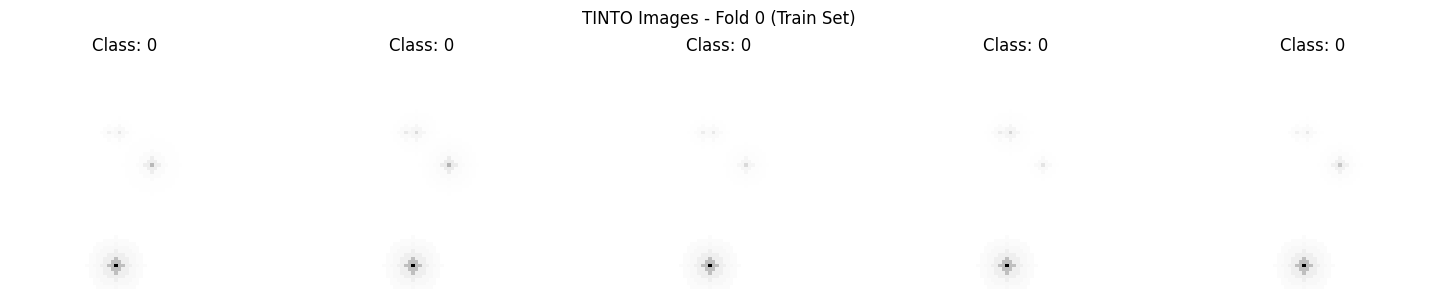


****** Step 5: Prepare DataLoaders ******

=== Starting 5--fold TINTO Image Generation ===
Method: tinto
Standardize data: True
--------------------------------------------------

Processing Fold 1/5:
  - Training set: 120 samples
  - Validation set: 30 samples
 -> Data standardized for fold 0
 -> Training images already exist (Fold 0)
 -> validation images already exist (Fold 0)

Processing Fold 2/5:
  - Training set: 120 samples
  - Validation set: 30 samples
 -> Data standardized for fold 1
 -> Training images already exist (Fold 1)
 -> validation images already exist (Fold 1)

Processing Fold 3/5:
  - Training set: 120 samples
  - Validation set: 30 samples
 -> Data standardized for fold 2
 -> Training images already exist (Fold 2)
 -> validation images already exist (Fold 2)

Processing Fold 4/5:
  - Training set: 120 samples
  - Validation set: 30 samples
 -> Data standardized for fold 3
 -> Training images already exist (Fold 3)
 -> validation images already exist (Fold 3)

Pro

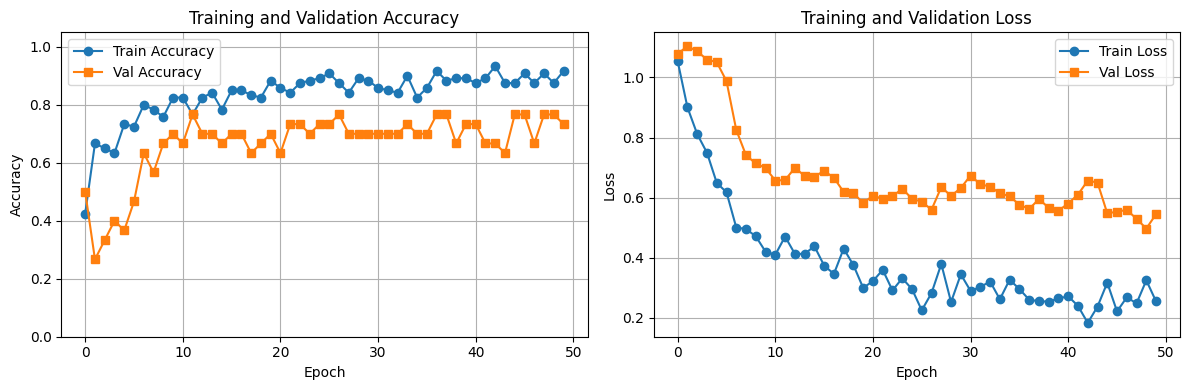

Training curves saved to: D:\Develop\PyTorch_26Project\output\results\training_curves.png

 Pipeline completed!
 Images saved to:  D:\Develop\PyTorch_26Project\output\tinto_images
 Results saved to:  D:\Develop\PyTorch_26Project\output\results


In [107]:
def run_full_pipeline(skip_data_loading_check=True,
                      start_training=True,
                      fine_tune_all=True
                     ):
    """
    Run the complete image generation and data preparation pipeline

    Args:
        skip_data_loading_check: Skip cheing DataLoader
        start_training: Start transfer learning training
        fine_tune_all: fine-tune all layers with different learning rates
    """

    print("="*60)
    print("TINTO Image Generation and 5-Fold CV complete Pipeline")
    print("="*60)

    # Step 1: Load data
    print("\n****** Step 1: Loading Iris dataset ********")
    X, y, feature_names, target_names = load_iris_data(iris_data_path)

    
    # Step 2: Generate 5-fold TINTO images
    print("\n****** Step 2: Generate 5-fold TINTO images ******")
    tinto_data = create_5fold_tinto_images(X, y, method_name='tinto', standardize=True)

    
    # Step 3: Check generation results
    print("\n****** Step 3: Check generation results ******")
    for fold_name, fold_data in tinto_data.items():
        train_count = len(fold_data['train']['images'])
        val_count = len(fold_data['val']['images'])
        print(f" {fold_name}: Training {train_count} images,"
              f"Validation {val_count} images")

    
    # Step 4: Visualize examples
    print("\n****** Step 4: Visualize example images ******")
    visualize_tinto_images(tinto_data['fold_0'], fold_idx=0)

    
    # Step 5: Prepare DataLoaders
    print("\n****** Step 5: Prepare DataLoaders ******")
    train_loader, val_loader = get_fold_dataloaders(
        fold_idx=0, 
        batch_size=Config.BATCH_SIZE, 
        num_workers=0,
        use_simple_normalization=True  # use simple normalization for TINTO images
    )

    
    # Step 6: Check image shapes
    print("\n****** Step 6: Check image shapes ******")    
    for images, labels in train_loader:
        print(f" Image batch shape: {images.shape}")
        print(f" Label batch shape: {labels.shape}")
        break

    
    # Step 7: Start Transfer learning Training
    if start_training:
        print("\n****** Step 7: Start Transfer learning Training ******")
        history, model = train_transfer_learning(
            fold_idx=0,
            epochs=Config.EPOCHS,
            method_name='tinto',
            save_model=True,
            fine_tune_all=fine_tune_all
        )

        # Plot training curves
        plot_training_curves(history)
    else:
        print("\n****** Step 7: Training skipped ******")
        print("  Images are ready for transfer learning")
        print("  You can run train_transfer_learning() manually")
        
    print("\n" + "="*60)
    print(" Pipeline completed!")
    print(" Images saved to: ", Config.TINTO_DIR)
    print(" Results saved to: ", Config.RESULTS_DIR)    
    print("="*60)


# Execute the full pipeline
#run_full_pipeline(skip_data_loading_check=True, start_training=False)

# Generate images and start training 
if __name__ == "__main__":
    run_full_pipeline(
        skip_data_loading_check=True,
        start_training=True,
        fine_tune_all=True
    )
    